# OSD 时间戳 OCR 测试

验证两个相机的 OSD 时间戳读取效果。
每张图片文件名包含帧号和预期时间（从 cam68 推算）。

**请肉眼确认每张图片的实际 OSD 时间，特别是 cam66 的。**

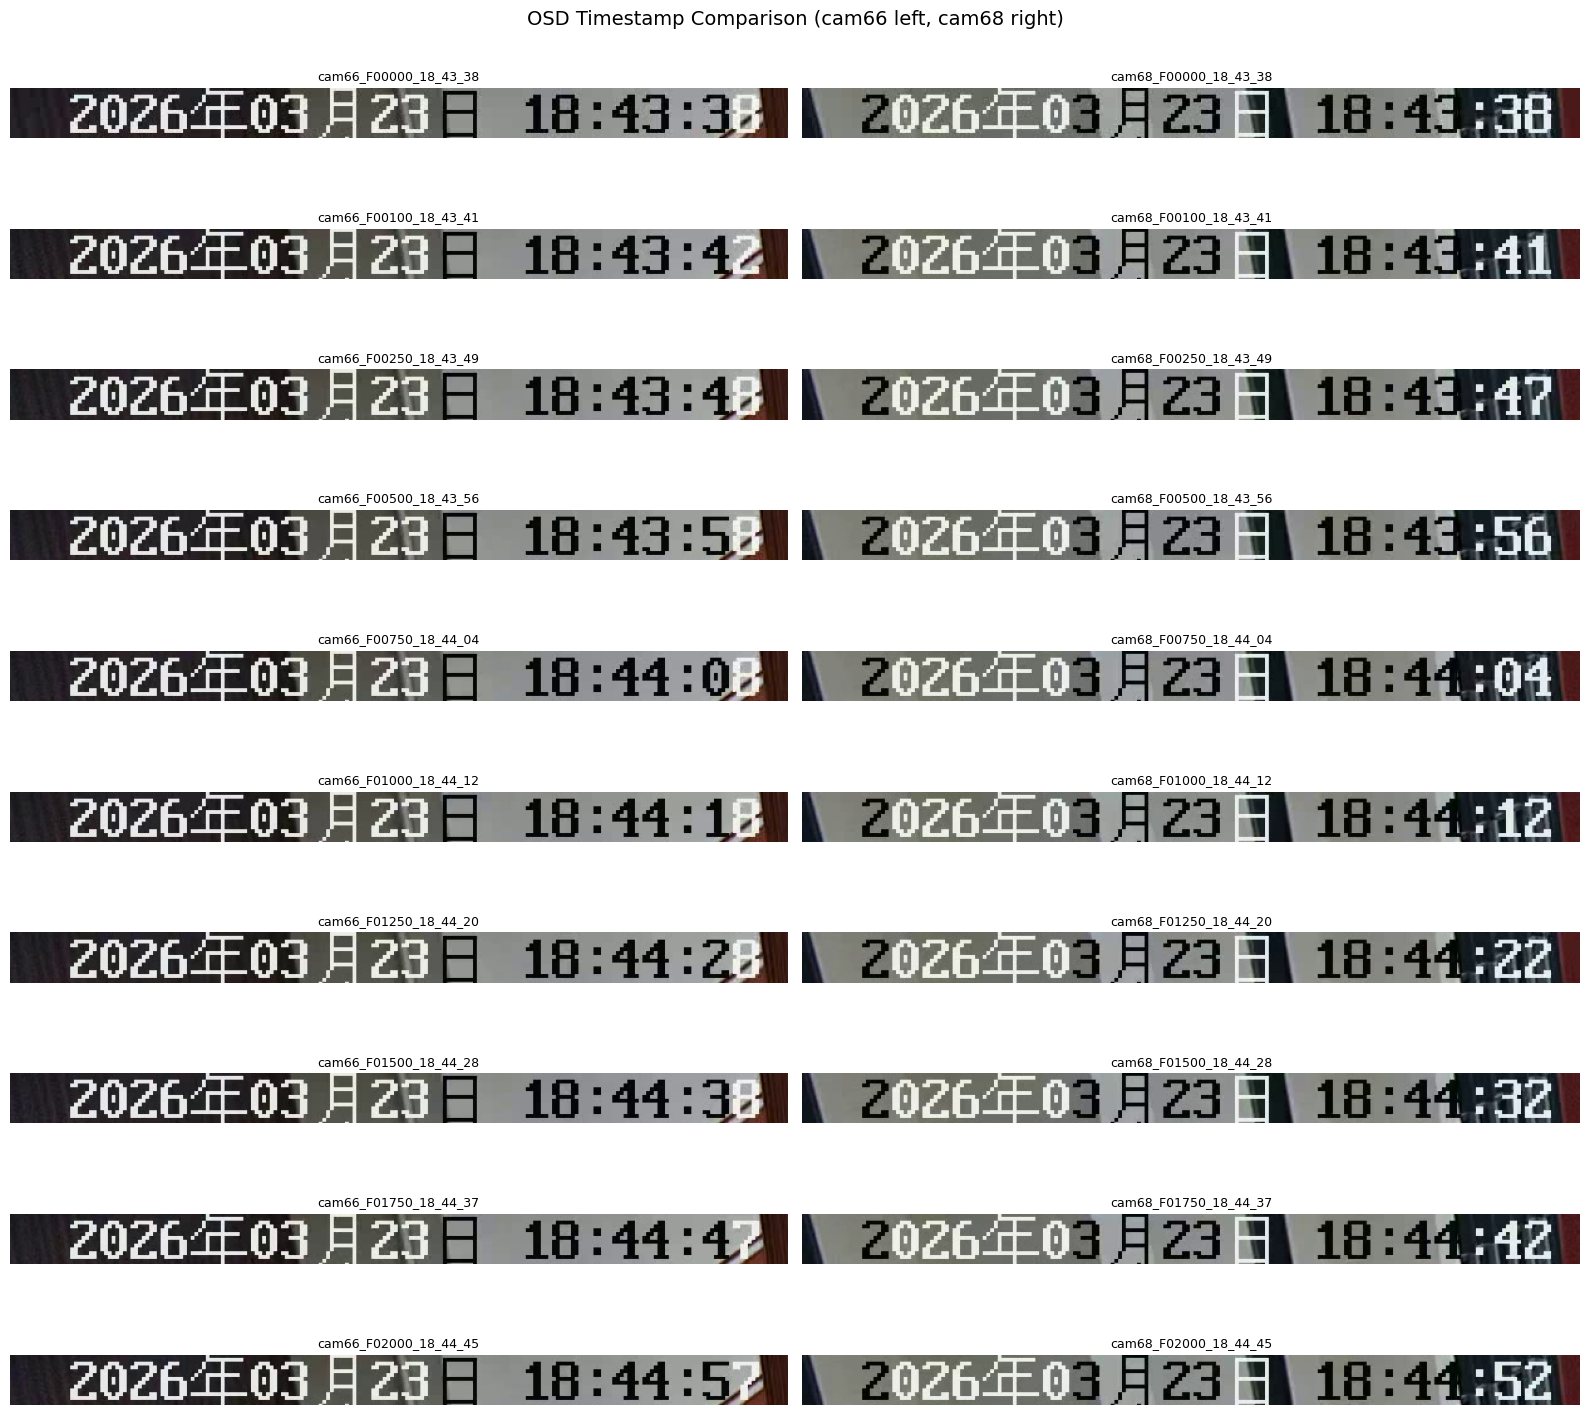

In [2]:
import os, cv2
import matplotlib.pyplot as plt
import numpy as np

digit_dir = 'osd_digits'
files = sorted(os.listdir(digit_dir))

# Show all cam66 samples
cam66_files = [f for f in files if f.startswith('cam66')]
cam68_files = [f for f in files if f.startswith('cam68')]

fig, axes = plt.subplots(len(cam66_files), 2, figsize=(16, len(cam66_files)*1.5))
fig.suptitle('OSD Timestamp Comparison (cam66 left, cam68 right)', fontsize=14)

for i, (f66, f68) in enumerate(zip(cam66_files, cam68_files)):
    img66 = cv2.imread(os.path.join(digit_dir, f66))
    img68 = cv2.imread(os.path.join(digit_dir, f68))
    
    axes[i][0].imshow(cv2.cvtColor(img66, cv2.COLOR_BGR2RGB))
    axes[i][0].set_title(f66.replace('.jpg',''), fontsize=9)
    axes[i][0].axis('off')
    
    axes[i][1].imshow(cv2.cvtColor(img68, cv2.COLOR_BGR2RGB))
    axes[i][1].set_title(f68.replace('.jpg',''), fontsize=9)
    axes[i][1].axis('off')

plt.tight_layout()
plt.show()

## 手动确认 OSD 时间

请在下面表格里填写你肉眼看到的 OSD 时间（HH:MM:SS）：

| Frame | cam66 OSD | cam68 OSD | 差值(秒) |
|-------|-----------|-----------|----------|
| 0     |           |           |          |
| 100   |           |           |          |
| 250   |           |           |          |
| 500   |           |           |          |
| 750   |           |           |          |
| 1000  |           |           |          |
| 1250  |           |           |          |
| 1500  |           |           |          |
| 1750  |           |           |          |
| 2000  |           |           |          |

In [9]:
# After you fill the table above, enter the data here:
# Format: (frame, cam66_seconds_since_start, cam68_seconds_since_start)
# Example: frame 0 both show 43:38 -> both are 0 seconds since start
# frame 500 cam66 shows 43:58 (20s elapsed), cam68 shows 43:56 (18s elapsed)

manual_readings = [
    # (frame, cam66_elapsed_sec, cam68_elapsed_sec)
    # (0,     0,   0),
    # (500,   20,  18),
    # (1000,  40,  34),
    # Fill in after visual inspection...
]

if manual_readings:
    frames = [r[0] for r in manual_readings]
    elapsed66 = [r[1] for r in manual_readings]
    elapsed68 = [r[2] for r in manual_readings]
    
    # Calculate OSD rate for each camera
    # OSD seconds per frame = elapsed / frame_number
    from numpy.polynomial import polynomial as P
    
    # Linear fit: elapsed = rate * frame
    rate66 = np.polyfit(frames, elapsed66, 1)[0]
    rate68 = np.polyfit(frames, elapsed68, 1)[0]
    
    print(f'cam66 OSD rate: {rate66:.6f} OSD-seconds per frame ({rate66*25:.4f} OSD-sec per real-sec)')
    print(f'cam68 OSD rate: {rate68:.6f} OSD-seconds per frame ({rate68*25:.4f} OSD-sec per real-sec)')
    print()
    
    # To align: find cam68 frame that shows same OSD time as cam66 frame
    # cam66_elapsed = rate66 * f66
    # cam68_elapsed = rate68 * f68
    # Set equal: rate66 * f66 = rate68 * f68
    # f68 = f66 * rate66 / rate68
    
    ratio = rate66 / rate68
    print(f'Alignment ratio: cam68_frame = cam66_frame * {ratio:.4f}')
    print()
    
    # Verify
    print('Verification:')
    print(f'{"Frame":>7} {"cam66 OSD":>10} {"cam68 frame":>12} {"cam68 OSD":>10} {"diff":>6}')
    for f66 in [0, 500, 1000, 1500, 2000, 2500, 3000]:
        osd66 = rate66 * f66
        f68 = int(f66 * ratio)
        osd68 = rate68 * f68
        diff = osd66 - osd68
        print(f'{f66:>7} {osd66:>10.1f}s {f68:>12} {osd68:>10.1f}s {diff:>+6.1f}s')
else:
    print('Please fill in manual_readings first!')

Please fill in manual_readings first!


## Tesseract OCR 测试

对比 OCR 读取结果和你肉眼看到的时间：

In [3]:
import pytesseract, re
pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

for cam in ['cam66', 'cam68']:
    print(f'=== {cam} ===')
    cam_files = [f for f in files if f.startswith(cam)]
    
    for f in cam_files:
        img = cv2.imread(os.path.join(digit_dir, f))
        
        
        text = pytesseract.image_to_string(img)
        
        expected = f.split('_')[2] + ':' + f.split('_')[3] + ':' + f.split('_')[4].replace('.jpg','')
        print(f'  {f:45s} expected={expected:10s} OCR=[{text}]')
    print()

=== cam66 ===
  cam66_F00000_18_43_38.jpg                     expected=18:43:38   OCR=[03 823 Stee ees
]
  cam66_F00100_18_43_41.jpg                     expected=18:43:41   OCR=[]
  cam66_F00250_18_43_49.jpg                     expected=18:43:49   OCR=[]
  cam66_F00500_18_43_56.jpg                     expected=18:43:56   OCR=[03 82735 Stee eae
]
  cam66_F00750_18_44_04.jpg                     expected=18:44:04   OCR=[267009 B23 Ss eeE ee
]
  cam66_F01000_18_44_12.jpg                     expected=18:44:12   OCR=[267609 825 Ss eee
]
  cam66_F01250_18_44_20.jpg                     expected=18:44:20   OCR=[267009 B25 See eee
]
  cam66_F01500_18_44_28.jpg                     expected=18:44:28   OCR=[267009 B25 See Rese
]
  cam66_F01750_18_44_37.jpg                     expected=18:44:37   OCR=[itera 14 :44:4
]
  cam66_F02000_18_44_45.jpg                     expected=18:44:45   OCR=[767603 B25 SU HeeER
]

=== cam68 ===
  cam68_F00000_18_43_38.jpg                     expected=18:43:38   OCR=[]

In [11]:



 
from paddleocr import TextRecognition
model = TextRecognition(model_name="PP-OCRv5_server_rec")
output = model.predict(input=img, batch_size=1)
for res in output:
    print(res['rec_text'].strip()[-8:])

Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\PC\.paddlex\official_models\PP-OCRv5_server_rec`.


18：44：52


In [6]:
from paddleocr import TextRecognition

model = TextRecognition(
    model_name="PP-OCRv5_mobile_rec",
    model_dir=r"D:\tennis\tennis-3d-tracking\.claude\worktrees\elastic-goldberg\model_weight/PP-OCRv5_mobile_rec",
    enable_mkldnn=False
)
output = model.predict(input=img, batch_size=1)
for res in output:
    print(res['rec_text'])

2026年03月23日18：44:52


In [ ]:
import paddle
import paddleocr
print("paddle:", paddle.__version__)
print("paddleocr:", paddleocr.__version__)


paddle: 3.3.1
paddleocr: 3.4.0
